# **Environment Preparation**

In [1]:
!pip install datascope

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.4 MB/s eta 0:00:00
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.8/259.8 kB 17.5 MB/s eta 0:00:00
  Created wheel for datascope: filename=datascope-0.0.32-cp311-cp311-linux_x86_64.whl size=195802 sha256=c3e7ba2914f96ad3a962697c17bd7d8fe8b993061b9bcf61683626b1abb41abc
  Stored in directory: /root/.cache/pip/wheels/67/c8/5a/d7857d2405cd97a220eef802f46f049d703710fd91d308728a
Successfully built datascope
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfull

In [2]:
!pip uninstall numpy
!pip install numpy==1.26.4

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/lib/python3.11/dist-packages/numpy-1.26.4.dist-info/*
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libgfortran-040039e1.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libopenblas64_p-r0-0cf96a72.3.23.dev.so
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libquadmath-96973f99.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/numpy/*
Proceed (Y/n)? Y
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which 

In [3]:
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 4.5 MB/s eta 0:00:00


In [ ]:
# This will restart the Colab runtime
import os
os.kill(os.getpid(), 9)

# **Data Debugging Experiment on German Credit using MLP and GB**

In [1]:
import copy
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

# Set seed for reproducibility
SEED = 0
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load the German Credit dataset
print("Loading German Credit dataset...")
data = fetch_openml(name='credit-g', as_frame=True)
X_frame, y_frame = data["data"].copy(), data["target"].copy()

# Preprocess the target variable
y_frame = pd.Series(LabelEncoder().fit_transform(y_frame).flatten())
y_frame = y_frame.replace({0: -1})  # Convert to -1/1 for better loss handling

# Handle categorical variables
categorical_columns = X_frame.select_dtypes(include=['category', 'object']).columns
X_processed = pd.get_dummies(X_frame, columns=categorical_columns, drop_first=True)

# Scale numerical features
numerical_columns = X_frame.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
X_processed[numerical_columns] = scaler.fit_transform(X_processed[numerical_columns])

# Convert to numpy arrays
X, y = X_processed.to_numpy(), y_frame.to_numpy()

# Split the dataset into train and test sets
N_TRAIN, N_VAL, N_TEST = 700, 150, 150  # Adjusted for German Credit dataset's size (~1000 samples)

X_train, X_test, y_train, y_test = train_test_split(X, y,
                train_size=N_TRAIN+N_VAL, test_size=N_TEST, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                train_size=N_TRAIN, test_size=N_VAL, random_state=SEED)

Loading German Credit dataset...


/usr/local/lib/python3.11/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name credit-g exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=31
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=44096

  warn(warning_msg)


In [2]:
X_train_dirty, y_train_dirty = copy.deepcopy(X_train), copy.deepcopy(y_train)
dirty_idx = np.random.RandomState(seed=SEED).choice(a=[False, True], size=(N_TRAIN), p=[0.8, 0.2])
y_train_dirty[dirty_idx] = 1 - y_train[dirty_idx]

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

imputer = SimpleImputer(strategy='most_frequent')

numeric_features = ["duration", "credit_amount", "installment_commitment",
                    "age", "existing_credits", "num_dependents"]
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)

categorical_features = ["checking_status", "credit_history", "purpose", "savings_status",
                    "employment", "personal_status", "other_parties", "property_magnitude",
                    "other_payment_plans", "housing", "job", "own_telephone", "foreign_worker"]
categorical_transformer = OrdinalEncoder(handle_unknown="use_encoded_value",
                                         unknown_value=-1)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,
         [X_frame.columns.get_loc(x) for x in numeric_features]),
        ("cat", categorical_transformer,
         [X_frame.columns.get_loc(x) for x in categorical_features]),
    ]
)

model = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,
                        max_depth=8, random_state=SEED)

pipeline_gb = Pipeline([
    ("missing_val_impute", imputer ),
    ("preprocessor", preprocessor),
    ("model", model),
])

pipeline_gb.fit(X_train, y_train)
y_pred = pipeline_gb.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Pipeline accuracy in the beginning:", accuracy)

Pipeline accuracy in the beginning: 0.7266666666666667


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score

imputer = SimpleImputer(strategy='most_frequent')

numeric_features = ["duration", "credit_amount", "installment_commitment",
                    "age", "existing_credits", "num_dependents"]
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)

categorical_features = ["checking_status", "credit_history", "purpose", "savings_status",
                    "employment", "personal_status", "other_parties", "property_magnitude",
                    "other_payment_plans", "housing", "job", "own_telephone", "foreign_worker"]
categorical_transformer = OrdinalEncoder(handle_unknown="use_encoded_value",
                                         unknown_value=-1)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,
         [X_frame.columns.get_loc(x) for x in numeric_features]),
        ("cat", categorical_transformer,
         [X_frame.columns.get_loc(x) for x in categorical_features]),
    ]
)

model = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                   max_iter=1000, alpha=0.0001, solver='adam', random_state=SEED)

pipeline_mlp = Pipeline([
    ("missing_val_impute", imputer ),
    ("preprocessor", preprocessor),
    ("model", model),
])

pipeline_mlp.fit(X_train, y_train)
y_pred = pipeline_mlp.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Pipeline accuracy in the beginning:", accuracy)

Pipeline accuracy in the beginning: 0.74


In [10]:
from datascope.importance import SklearnModelAccuracy
from datascope.importance.shapley import ShapleyImportance, ImportanceMethod

model_in_pipeline = pipeline_gb[-1]
utility = SklearnModelAccuracy(model_in_pipeline)

feature_pipelines = pipeline_gb[:-1]
importances_gb = ShapleyImportance(method=ImportanceMethod.NEIGHBOR,
                               pipeline=feature_pipelines, utility=utility)

importances_gb = importances_gb.fit(X_train_dirty, y_train_dirty).score(X_val, y_val)

In [11]:
from datascope.importance import SklearnModelAccuracy
from datascope.importance.shapley import ShapleyImportance, ImportanceMethod

model_in_pipeline = pipeline_mlp[-1]
utility = SklearnModelAccuracy(model_in_pipeline)

feature_pipelines = pipeline_mlp[:-1]
importances_mlp = ShapleyImportance(method=ImportanceMethod.NEIGHBOR,
                               pipeline=feature_pipelines, utility=utility)

importances_mlp = importances_mlp.fit(X_train_dirty, y_train_dirty).score(X_val, y_val)

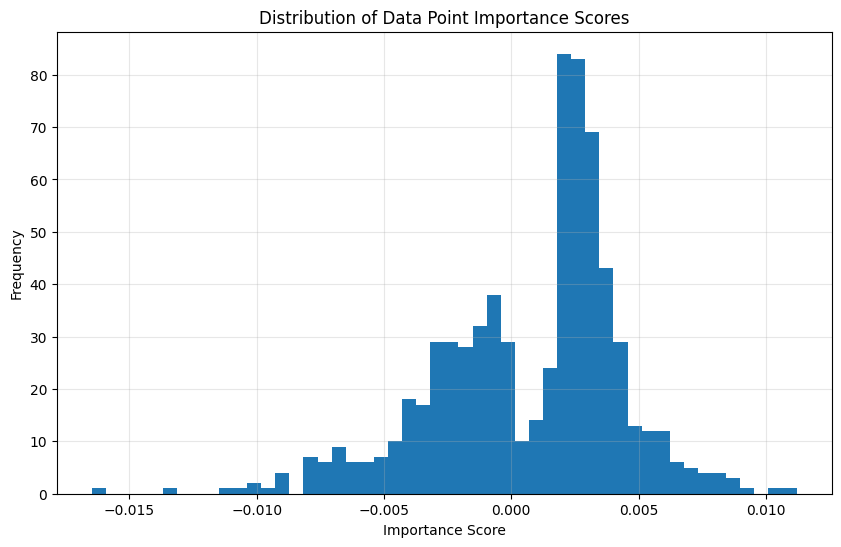

Top 20 most influential data points:
Index 265: Importance score = 0.011206
Index 460: Importance score = 0.010477
Index 207: Importance score = 0.009274
Index 375: Importance score = 0.008723
Index 584: Importance score = 0.008666
Index 22: Importance score = 0.008577
Index 267: Importance score = 0.008290
Index 390: Importance score = 0.008215
Index 0: Importance score = 0.007983
Index 491: Importance score = 0.007948
Index 242: Importance score = 0.007562
Index 657: Importance score = 0.007522
Index 125: Importance score = 0.007499
Index 436: Importance score = 0.007428
Index 67: Importance score = 0.007293
Index 652: Importance score = 0.007278
Index 676: Importance score = 0.007257
Index 234: Importance score = 0.007032
Index 317: Importance score = 0.006939
Index 470: Importance score = 0.006668


In [12]:
from matplotlib import pyplot as plt
import numpy as np

problem_idx = np.argsort(importances_gb)[::-1]  # Sort in descending order
# Let's visualize the distribution of importance scores
plt.figure(figsize=(10, 6))
plt.hist(importances_gb, bins=50)
plt.title('Distribution of Data Point Importance Scores')
plt.xlabel('Importance Score')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

# Print the most influential data points (potential problems)
print("Top 20 most influential data points:")
for idx in problem_idx[:20]:
    print(f"Index {idx}: Importance score = {importances_gb[idx]:.6f}")

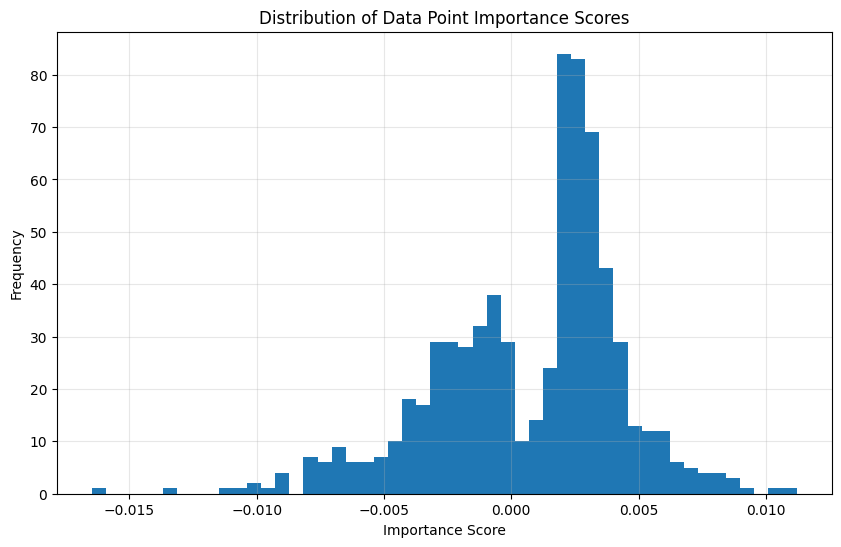

Top 20 most influential data points:
Index 265: Importance score = 0.011206
Index 460: Importance score = 0.010477
Index 207: Importance score = 0.009274
Index 375: Importance score = 0.008723
Index 584: Importance score = 0.008666
Index 22: Importance score = 0.008577
Index 267: Importance score = 0.008290
Index 390: Importance score = 0.008215
Index 0: Importance score = 0.007983
Index 491: Importance score = 0.007948
Index 242: Importance score = 0.007562
Index 657: Importance score = 0.007522
Index 125: Importance score = 0.007499
Index 436: Importance score = 0.007428
Index 67: Importance score = 0.007293
Index 652: Importance score = 0.007278
Index 676: Importance score = 0.007257
Index 234: Importance score = 0.007032
Index 317: Importance score = 0.006939
Index 470: Importance score = 0.006668


In [13]:
from matplotlib import pyplot as plt
import numpy as np

problem_idx = np.argsort(importances_mlp)[::-1]  # Sort in descending order
# Let's visualize the distribution of importance scores
plt.figure(figsize=(10, 6))
plt.hist(importances_mlp, bins=50)
plt.title('Distribution of Data Point Importance Scores')
plt.xlabel('Importance Score')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

# Print the most influential data points (potential problems)
print("Top 20 most influential data points:")
for idx in problem_idx[:20]:
    print(f"Index {idx}: Importance score = {importances_mlp[idx]:.6f}")

In [14]:
# Create a DataFrame for better visualization of problematic data points
import pandas as pd
top_problematic = pd.DataFrame({
    'Index': problem_idx[:20],
    'Importance': [importances_mlp[idx] for idx in problem_idx[:20]],
    'Dirty_Label': [y_train_dirty[idx] for idx in problem_idx[:20]],
    'True_Label': [y_train[idx] for idx in problem_idx[:20]],
    'Is_Mislabeled': [y_train_dirty[idx] != y_train[idx] for idx in problem_idx[:20]]
})

In [15]:
print("\nSummary of top problematic data points:")
top_problematic


Summary of top problematic data points:


,Index,Importance,Dirty_Label,True_Label,Is_Mislabeled
0,265,0.011206,1,1,False
1,460,0.010477,1,1,False
2,207,0.009274,1,1,False
3,375,0.008723,1,1,False
4,584,0.008666,1,1,False
5,22,0.008577,1,1,False
6,267,0.008290,1,1,False
7,390,0.008215,1,1,False
8,0,0.007983,1,1,False
9,491,0.007948,1,1,False


In [16]:
# Extract the corresponding rows from X_train_dirty
# If X_train_dirty is a DataFrame, use iloc for position-based indexing
if isinstance(X_train_dirty, pd.DataFrame):
    problematic_samples = X_train_dirty.iloc[top_problematic['Index']].copy()
else:
    # If it's a numpy array
    problematic_samples = pd.DataFrame(X_train_dirty[top_problematic['Index']])

print("Extracted problematic samples from X_train_dirty:")
problematic_samples

Extracted problematic samples from X_train_dirty:


,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
0,-0.240857,0.18032,0.024147,-0.765977,-0.048022,1.027079,-0.42829,False,False,True,...,True,True,False,True,False,False,False,False,True,True
1,-0.240857,-0.637381,0.024147,1.046987,0.303788,-0.704926,-0.42829,False,False,True,...,False,True,False,True,False,False,False,True,True,True
2,-0.489762,-0.635608,0.918477,0.140505,-0.223927,1.027079,-0.42829,False,False,True,...,False,False,False,True,False,False,False,True,False,True
3,-0.240857,-0.078778,-1.764514,-1.672459,0.831502,-0.704926,-0.42829,False,True,False,...,False,False,True,True,False,False,True,False,False,True
4,-0.738668,-0.74903,0.024147,-1.672459,-0.839594,-0.704926,-0.42829,False,False,False,...,True,True,False,True,False,False,False,True,True,True
5,-0.655699,-0.846857,0.918477,1.046987,-1.103451,1.027079,-0.42829,False,False,False,...,False,True,False,True,False,False,False,True,False,True
6,-0.987573,-0.167389,-0.870183,-0.765977,0.03993,1.027079,2.334869,True,False,False,...,False,True,False,False,True,False,False,True,False,True
7,-0.489762,-0.171288,-0.870183,0.140505,-1.015499,1.027079,-0.42829,False,False,True,...,True,False,False,True,False,False,False,True,False,True
8,-0.240857,-0.644469,0.024147,-1.672459,-0.839594,-0.704926,-0.42829,False,False,True,...,False,True,False,True,False,False,False,True,False,True
9,1.003669,1.411302,0.024147,-0.765977,-0.048022,1.027079,-0.42829,False,False,True,...,True,True,False,True,False,False,False,False,True,True


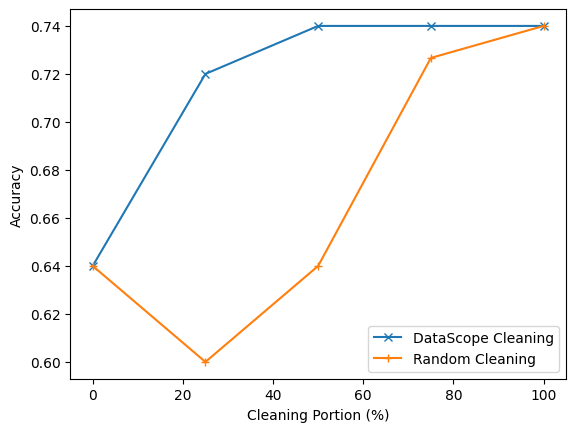

In [17]:
random_cleaning_acc = []
datascope_cleaning_acc = []

MAX_CLEAN_PERCENT = 100 + 1
STEP_PERCENT = 25

# clean with datascope
for cleaning_portion in range(0, MAX_CLEAN_PERCENT, STEP_PERCENT):

    target_idx = np.argsort(importances_mlp)[:int(cleaning_portion * N_TRAIN / 100)]
    X_train_repaired, y_train_repaired = np.copy(X_train_dirty), np.copy(y_train_dirty)
    y_train_repaired[target_idx] = y_train[target_idx]
    pipeline_mlp.fit(X_train_repaired, y_train_repaired)
    y_pred = pipeline_mlp.predict(X_test)
    accuracy_repaired = accuracy_score(y_test, y_pred)

    datascope_cleaning_acc.append(accuracy_repaired)

# clean with random
np.random.seed(65535)
random_importances = np.random.rand(len(importances_mlp))
for cleaning_portion in range(0, MAX_CLEAN_PERCENT, STEP_PERCENT):

    target_idx = np.argsort(random_importances)[:int(cleaning_portion * N_TRAIN / 100)]
    X_train_repaired, y_train_repaired = np.copy(X_train_dirty), np.copy(y_train_dirty)
    y_train_repaired[target_idx] = y_train[target_idx]
    pipeline_mlp.fit(X_train_repaired, y_train_repaired)
    y_pred = pipeline_mlp.predict(X_test)
    accuracy_repaired = accuracy_score(y_test, y_pred)

    random_cleaning_acc.append(accuracy_repaired)

# Plot
import matplotlib.pyplot as plt
plt.plot(range(0, MAX_CLEAN_PERCENT, STEP_PERCENT), datascope_cleaning_acc, '-x', label="DataScope Cleaning")
plt.plot(range(0, MAX_CLEAN_PERCENT, STEP_PERCENT), random_cleaning_acc, '-+', label="Random Cleaning")
plt.xlabel("Cleaning Portion (%)")
plt.ylabel("Accuracy")
plt.legend()

In [18]:
# prompt: generate code to remove the data points in top problematic and retrain the model to print accuracy

# Remove the top problematic data points and retrain the model
# Assuming 'top_problematic' DataFrame and 'X_train_dirty', 'y_train_dirty' are defined as in the previous code
num_to_remove = 20  # Number of top problematic data points to remove
indices_to_keep = ~np.isin(np.arange(len(X_train_dirty)), top_problematic['Index'].values)
X_train_cleaned = X_train_dirty[indices_to_keep]
y_train_cleaned = y_train_dirty[indices_to_keep]

# Retrain the model with the cleaned data
pipeline_mlp.fit(X_train_cleaned, y_train_cleaned)

# Evaluate the model on the test set
y_pred_cleaned = pipeline_mlp.predict(X_test)
accuracy_cleaned = accuracy_score(y_test, y_pred_cleaned)

print(f"Accuracy after removing top {num_to_remove} problematic data points: {accuracy_cleaned}")

Accuracy after removing top 20 problematic data points: 0.64


# **Fairness Debugging Experiment on German Credit Using MLP and GB**

Loaded dataset with shape: (1000, 23)

Data Statistics:
       classification  gender    age_group
count     1000.000000  1000.0  1000.000000
mean         0.700000     1.0     0.629000
std          0.458487     0.0     0.483314
min          0.000000     1.0     0.000000
25%          0.000000     1.0     0.000000
50%          1.000000     1.0     1.000000
75%          1.000000     1.0     1.000000
max          1.000000     1.0     1.000000

Class distribution by gender:
classification    0    1
gender                  
1               0.3  0.7
Train: (600, 20), Validation: (200, 20), Test: (200, 20)
Categorical features at indices: [0, 2, 3, 5, 6, 8, 9, 11, 13, 14, 16, 18, 19]
Numeric features at indices: [1, 4, 7, 10, 12, 15, 17]
Injected 10.0% label noise: 60 labels flipped
Baseline Accuracy: 0.7200
Baseline Equalized Odds Difference: 0.0000

Calculating accuracy-based Shapley values...
Calculating fairness-based Shapley values...

Overlap in top 60 points: 8 (13.3%)
Overlap in bottom

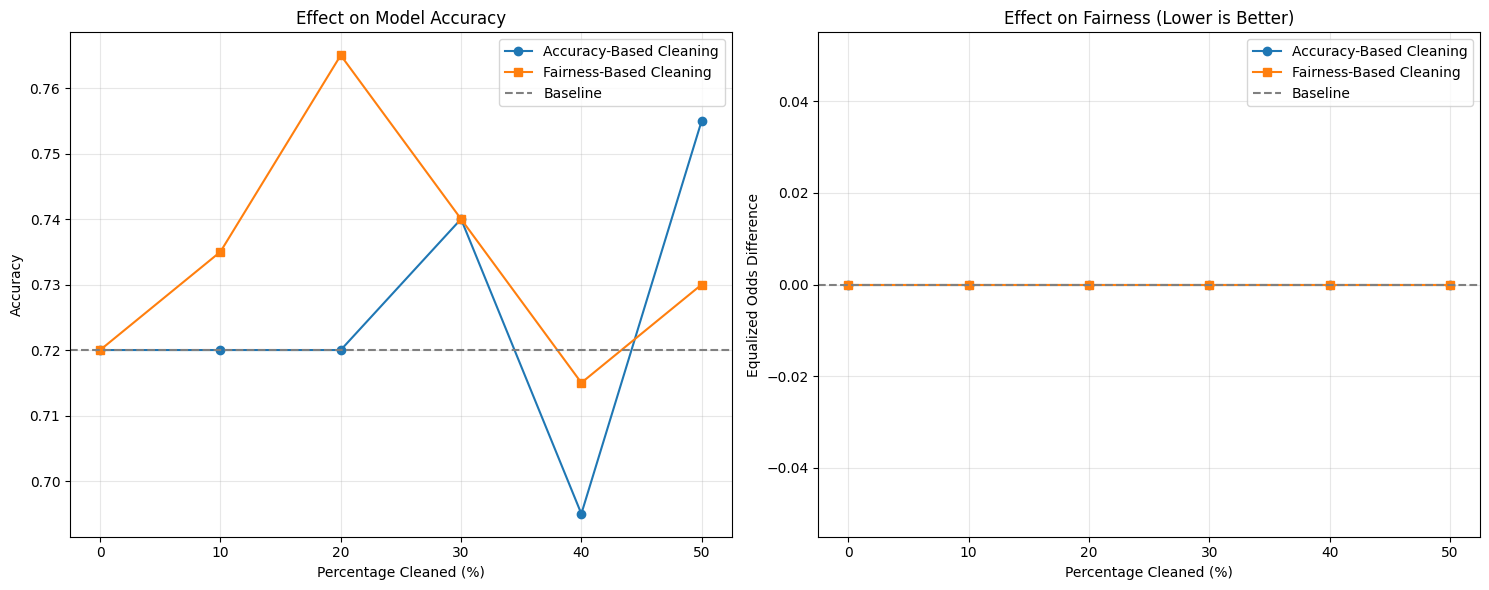

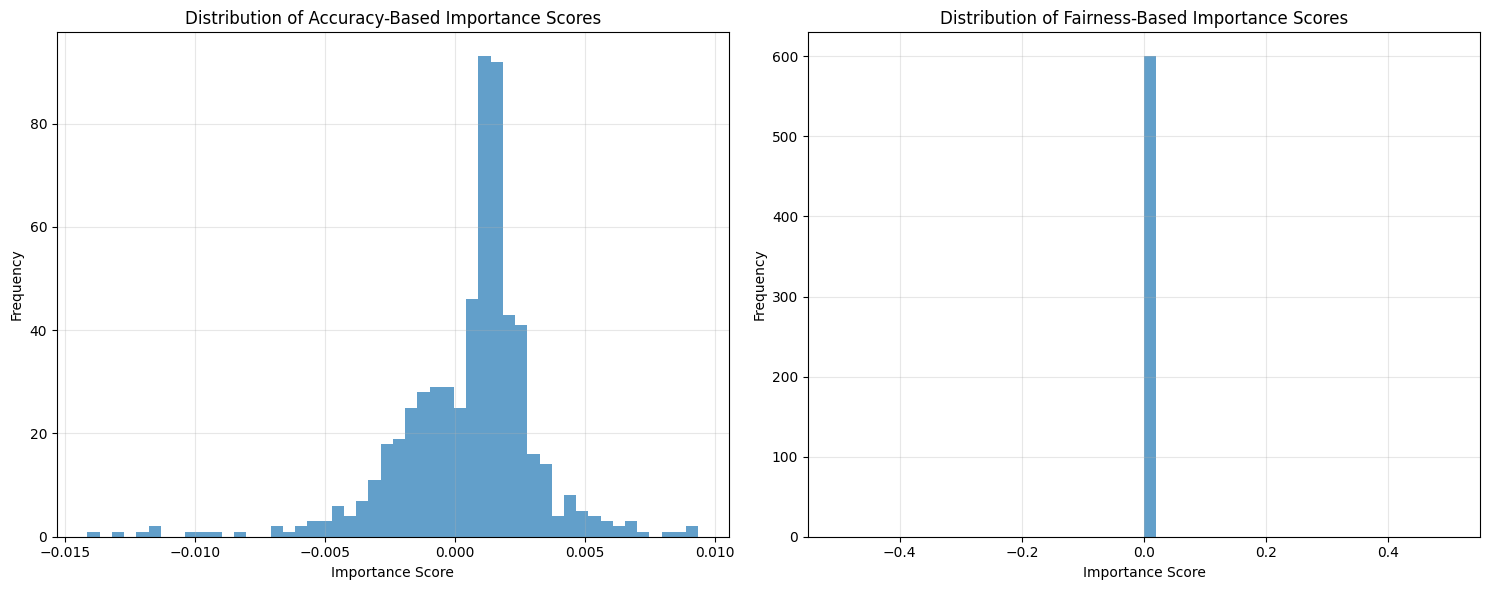


Gender distribution in important points:
Overall dataset: {0: 0.0, 1: 1.0}
Accuracy-based top points: {0: 0.0, 1: 1.0}
Fairness-based top points: {0: 0.0, 1: 1.0}


In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
import seaborn as sns

# Import datascope components
from datascope.importance.shapley import ShapleyImportance, ImportanceMethod
from datascope.importance import SklearnModelAccuracy, SklearnModelEqualizedOddsDifference

# Load the German Credit Risk dataset
def load_german_credit():
    """Load the German Credit Risk dataset and preprocess it."""
    # URL for the dataset
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

    # Column names according to the UCI documentation
    column_names = [
        "status", "duration", "credit_history", "purpose", "credit_amount",
        "savings", "employment", "installment_rate", "personal_status_sex",
        "other_debtors", "present_residence", "property", "age",
        "other_installment_plans", "housing", "existing_credits",
        "job", "num_dependents", "telephone", "foreign_worker", "classification"
    ]

    # Load the dataset
    df = pd.read_csv(url, sep=' ', names=column_names)

    # Convert classification to binary (1 = good, 0 = bad)
    # In the original dataset, 1 = good, 2 = bad
    df["classification"] = df["classification"].map({1: 1, 2: 0})

    # Extract gender from personal_status_sex
    df['gender'] = df['personal_status_sex'].apply(lambda x: 0 if 'male' in str(x).lower() else 1)

    # Create age groups (0: young, age < 30; 1: older, age >= 30)
    df['age_group'] = (df['age'] >= 30).astype(int)

    print(f"Loaded dataset with shape: {df.shape}")

    # Get column types
    categorical_feature_names = df.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric_feature_names = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Remove target and sensitive attributes
    features_to_remove = ['classification', 'gender', 'age_group']
    categorical_feature_names = [f for f in categorical_feature_names if f not in features_to_remove]
    numeric_feature_names = [f for f in numeric_feature_names if f not in features_to_remove]

    return df, categorical_feature_names, numeric_feature_names

# Build ML pipeline with MLP classifier using indices
def build_pipeline(X_train, categorical_indices, numeric_indices):
    """Build a scikit-learn pipeline that works with numpy arrays using column indices."""

    # Preprocessing for numerical features
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    # Preprocessing for categorical features
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # Combine preprocessing steps with indices
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_indices),
            ('cat', categorical_transformer, categorical_indices)
        ],
        remainder='drop'  # Drop any columns not specified
    )

    # Create pipeline with preprocessor and neural network classifier
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', MLPClassifier(
            hidden_layer_sizes=(100, 50),
            activation='relu',
            solver='adam',
            alpha=0.0001,
            batch_size=32,
            learning_rate='adaptive',
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=42
        ))
    ])

    return pipeline

# Compare accuracy and fairness importance
def compare_importance_methods(df, categorical_feature_names, numeric_feature_names, noise_ratio=0.2):
    """Compare Shapley importance based on accuracy versus fairness (equalized odds)."""

    # Split data into features and target
    X = df.drop(columns=['classification'])
    y = df['classification']

    # Extract sensitive attributes
    sensitive_attrs = X[['gender', 'age_group']]

    # Create feature columns for the model (excluding sensitive attrs)
    X_model = X.drop(columns=['gender', 'age_group'])

    # Get categorical and numeric indices based on their position in X_model
    all_features = X_model.columns.tolist()
    categorical_indices = [all_features.index(feat) for feat in categorical_feature_names if feat in all_features]
    numeric_indices = [all_features.index(feat) for feat in numeric_feature_names if feat in all_features]

    # Convert to numpy arrays before splitting
    X_model_array = X_model.to_numpy()
    y_array = y.to_numpy()
    gender_array = sensitive_attrs['gender'].to_numpy()

    # Split data into train/val/test using numpy arrays
    X_train_val, X_test, y_train_val, y_test, gender_train_val, gender_test = train_test_split(
        X_model_array, y_array, gender_array, test_size=0.2, random_state=42, stratify=y_array
    )

    X_train, X_val, y_train, y_val, gender_train, gender_val = train_test_split(
        X_train_val, y_train_val, gender_train_val, test_size=0.25, random_state=42, stratify=y_train_val
    )

    print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

    # Store column information for debugging and analysis
    feature_names = all_features
    print(f"Categorical features at indices: {categorical_indices}")
    print(f"Numeric features at indices: {numeric_indices}")

    # Inject label noise
    np.random.seed(42)
    y_train_dirty = y_train.copy()
    num_to_flip = int(len(y_train) * noise_ratio)
    indices_to_flip = np.random.choice(len(y_train), num_to_flip, replace=False)
    y_train_dirty[indices_to_flip] = 1 - y_train_dirty[indices_to_flip]

    print(f"Injected {noise_ratio*100}% label noise: {num_to_flip} labels flipped")

    # Keep clean copy for evaluation
    y_train_clean = y_train.copy()

    # Build pipeline
    pipeline = build_pipeline(X_train, categorical_indices, numeric_indices)

    # Fit pipeline on dirty data
    pipeline.fit(X_train, y_train_dirty)

    # Evaluate baseline performance
    y_pred = pipeline.predict(X_test)
    baseline_acc = accuracy_score(y_test, y_pred)
    baseline_eod = equalized_odds_difference(
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=gender_test
    )

    print(f"Baseline Accuracy: {baseline_acc:.4f}")
    print(f"Baseline Equalized Odds Difference: {baseline_eod:.4f}")

    # Access the model and preprocessor
    model_in_pipeline = pipeline.named_steps['classifier']
    preprocessor = pipeline.named_steps['preprocessor']

    # Create utility functions for Shapley
    accuracy_utility = SklearnModelAccuracy(model_in_pipeline)
    fairness_utility = SklearnModelEqualizedOddsDifference(
        model_in_pipeline,
        sensitive_features=gender_train  # Pass the sensitive features during initialization
    )

    # Calculate accuracy-based importance
    print("\nCalculating accuracy-based Shapley values...")
    accuracy_importance = ShapleyImportance(
        method=ImportanceMethod.NEIGHBOR,
        pipeline=preprocessor,
        utility=accuracy_utility
    )

    acc_importances = accuracy_importance.fit(X_train, y_train_dirty).score(X_val, y_val)

    # Calculate fairness-based importance
    print("Calculating fairness-based Shapley values...")
    fairness_importance = ShapleyImportance(
        method=ImportanceMethod.NEIGHBOR,
        pipeline=preprocessor,
        utility=fairness_utility
    )

    # For fairness utility, we need to pass the sensitive feature
    fairness_importances = fairness_importance.fit(X_train, y_train_dirty).score(X_val, y_val)


    # Get indices sorted by importance (most important first)
    acc_idx = np.argsort(acc_importances)[::-1]
    fairness_idx = np.argsort(fairness_importances)[::-1]

    # Compare the overlap between top and bottom points
    top_k = int(0.1 * len(acc_importances))
    acc_top = set(acc_idx[:top_k])
    fairness_top = set(fairness_idx[:top_k])

    acc_bottom = set(acc_idx[-top_k:])
    fairness_bottom = set(fairness_idx[-top_k:])

    top_overlap = len(acc_top.intersection(fairness_top))
    bottom_overlap = len(acc_bottom.intersection(fairness_bottom))

    print(f"\nOverlap in top {top_k} points: {top_overlap} ({100*top_overlap/top_k:.1f}%)")
    print(f"Overlap in bottom {top_k} points: {bottom_overlap} ({100*bottom_overlap/top_k:.1f}%)")

    # Clean data based on both importance methods and compare results
    cleaning_percentages = np.arange(0, 51, 10)  # 0%, 10%, ..., 50%
    acc_cleaning_acc = []
    acc_cleaning_eod = []
    fairness_cleaning_acc = []
    fairness_cleaning_eod = []

    # First, identify which points are actually mislabeled
    mislabeled = indices_to_flip.tolist()

    # Clean with accuracy-based importance
    print("\nEvaluating accuracy-based cleaning...")
    for cleaning_percent in cleaning_percentages:
        num_to_clean = int(cleaning_percent * len(y_train) / 100)
        idx_to_clean = acc_idx[:num_to_clean] if num_to_clean > 0 else []

        # Create a clean copy with corrections
        y_train_fixed = y_train_dirty.copy()
        if len(idx_to_clean) > 0:
            y_train_fixed[idx_to_clean] = y_train_clean[idx_to_clean]

        # Create a fresh pipeline and train
        clean_pipeline = build_pipeline(X_train, categorical_indices, numeric_indices)
        clean_pipeline.fit(X_train, y_train_fixed)

        # Evaluate
        y_pred = clean_pipeline.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        eod = equalized_odds_difference(
            y_true=y_test,
            y_pred=y_pred,
            sensitive_features=gender_test
        )

        acc_cleaning_acc.append(acc)
        acc_cleaning_eod.append(eod)

        # Calculate detection rate (how many mislabeled points were fixed)
        fixed_mislabeled = len(set(idx_to_clean).intersection(set(mislabeled)))
        detection_rate = fixed_mislabeled / len(mislabeled) if mislabeled else 0

        print(f"  {cleaning_percent}% cleaned - Accuracy: {acc:.4f}, EOD: {eod:.4f}, Detection: {detection_rate:.2f}")

    # Clean with fairness-based importance
    print("\nEvaluating fairness-based cleaning...")
    for cleaning_percent in cleaning_percentages:
        num_to_clean = int(cleaning_percent * len(y_train) / 100)
        idx_to_clean = fairness_idx[:num_to_clean] if num_to_clean > 0 else []

        # Create a clean copy with corrections
        y_train_fixed = y_train_dirty.copy()
        if len(idx_to_clean) > 0:
            y_train_fixed[idx_to_clean] = y_train_clean[idx_to_clean]

        # Create a fresh pipeline and train
        clean_pipeline = build_pipeline(X_train, categorical_indices, numeric_indices)
        clean_pipeline.fit(X_train, y_train_fixed)

        # Evaluate
        y_pred = clean_pipeline.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        eod = equalized_odds_difference(
            y_true=y_test,
            y_pred=y_pred,
            sensitive_features=gender_test
        )

        fairness_cleaning_acc.append(acc)
        fairness_cleaning_eod.append(eod)

        # Calculate detection rate (how many mislabeled points were fixed)
        fixed_mislabeled = len(set(idx_to_clean).intersection(set(mislabeled)))
        detection_rate = fixed_mislabeled / len(mislabeled) if mislabeled else 0

        print(f"  {cleaning_percent}% cleaned - Accuracy: {acc:.4f}, EOD: {eod:.4f}, Detection: {detection_rate:.2f}")

    # Plot the results
    plt.figure(figsize=(15, 6))

    # Plot accuracy comparison
    plt.subplot(1, 2, 1)
    plt.plot(cleaning_percentages, acc_cleaning_acc, 'o-', label='Accuracy-Based Cleaning')
    plt.plot(cleaning_percentages, fairness_cleaning_acc, 's-', label='Fairness-Based Cleaning')
    plt.axhline(y=baseline_acc, linestyle='--', color='gray', label='Baseline')
    plt.xlabel('Percentage Cleaned (%)')
    plt.ylabel('Accuracy')
    plt.title('Effect on Model Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)

    # Plot fairness comparison
    plt.subplot(1, 2, 2)
    plt.plot(cleaning_percentages, acc_cleaning_eod, 'o-', label='Accuracy-Based Cleaning')
    plt.plot(cleaning_percentages, fairness_cleaning_eod, 's-', label='Fairness-Based Cleaning')
    plt.axhline(y=baseline_eod, linestyle='--', color='gray', label='Baseline')
    plt.xlabel('Percentage Cleaned (%)')
    plt.ylabel('Equalized Odds Difference')
    plt.title('Effect on Fairness (Lower is Better)')
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('accuracy_vs_fairness_cleaning.png')
    plt.show()

    # Compare importance distributions
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.hist(acc_importances, bins=50, alpha=0.7)
    plt.title('Distribution of Accuracy-Based Importance Scores')
    plt.xlabel('Importance Score')
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.hist(fairness_importances, bins=50, alpha=0.7)
    plt.title('Distribution of Fairness-Based Importance Scores')
    plt.xlabel('Importance Score')
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('importance_distributions.png')
    plt.show()

    # Analyze the most influential points for both methods
    top_n = 20
    acc_top_points = acc_idx[:top_n]
    fairness_top_points = fairness_idx[:top_n]

    # Count gender distribution in top points
    acc_gender_distribution = np.bincount(gender_train[acc_top_points], minlength=2) / len(acc_top_points)
    fairness_gender_distribution = np.bincount(gender_train[fairness_top_points], minlength=2) / len(fairness_top_points)
    overall_gender_distribution = np.bincount(gender_train, minlength=2) / len(gender_train)

    print("\nGender distribution in important points:")
    print(f"Overall dataset: {dict(enumerate(overall_gender_distribution))}")
    print(f"Accuracy-based top points: {dict(enumerate(acc_gender_distribution))}")
    print(f"Fairness-based top points: {dict(enumerate(fairness_gender_distribution))}")

    return {
        'acc_importances': acc_importances,
        'fairness_importances': fairness_importances,
        'acc_cleaning_results': {
            'acc': acc_cleaning_acc,
            'eod': acc_cleaning_eod,
        },
        'fairness_cleaning_results': {
            'acc': fairness_cleaning_acc,
            'eod': fairness_cleaning_eod,
        },
        'cleaning_percentages': cleaning_percentages,
        'baseline': {
            'acc': baseline_acc,
            'eod': baseline_eod
        }
    }

# Main execution
if __name__ == "__main__":
    # Load dataset
    df, categorical_feature_names, numeric_feature_names = load_german_credit()

    # Display dataset info
    print("\nData Statistics:")
    print(df[['classification', 'gender', 'age_group']].describe())

    # Show class distribution by sensitive attributes
    print("\nClass distribution by gender:")
    print(pd.crosstab(df['gender'], df['classification'], normalize='index'))

    # Run experiments comparing accuracy and fairness debugging
    results = compare_importance_methods(df, categorical_feature_names, numeric_feature_names, noise_ratio=0.1)